# CVRIE: Unsupervised Clinical Symptom Clustering
## Categorizing Patient Testimonials using NLP and K-Means

### Overview
In medical informatics, the ability to automatically categorize unstructured patient data is crucial for efficient triage and resource allocation. This notebook explores the application of **Unsupervised Learning** to a dataset of patient testimonials. By leveraging Natural Language Processing (NLP) techniques, we aim to discover latent patterns and group similar medical cases without the need for pre-existing labels.

### Objectives
1. **Vectorization**: Convert raw text into numerical features using TF-IDF.
2. **Optimization**: Determine the optimal number of symptom clusters using the Elbow Method and Silhouette Analysis.
3. **Clustering**: Apply the K-Means algorithm to group testimonials.
4. **Interpretation**: Analyze top descriptive terms to validate cluster coherence.
5. **Visualization**: Use t-SNE for high-dimensional data projection and cluster verification.

## 1. Dataset Loading and Structural Parsing

We begin by importing our analytical stack and loading the `Student_Dataset.csv`. Given that medical datasets can sometimes have irregular formatting, we use a robust manual parsing approach to ensure data integrity during the ingestion phase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

data = []
with open('Student_Dataset.csv', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue

        import csv
        parts = list(csv.reader([line]))[0]
        
        if len(parts) == 2:
            data.append({'ID': parts[0], 'Color': '0x000000', 'Testimony': parts[1]})
        elif len(parts) >= 3:
            data.append({'ID': parts[0], 'Color': parts[1], 'Testimony': parts[2]})

df = pd.DataFrame(data)
print(f"Loaded {len(df)} records.")
df.head()

Loaded 1011 records.


,ID,Color,Testimony
0,﻿1,0x000000,On uneven paths the heel feels wobbly side‑to‑...
1,2,0x000000,"The feverish feeling eased, but I’m now breath..."
2,3,0x000000,"While working in the garden, I touched a metal..."
3,4,0x000000,A short sprint brought on a twinge in the midd...
4,5,0x000000,I accidentally left my hand on a hot mug for a...


## 2. Text Pre-processing & Feature Extraction

### Cleaning
To minimize noise, we normalize the text by converting it to lowercase and removing non-alphabetic characters (punctuation, numbers).

### Vectorization: TF-IDF
We employ the **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorizer. 
- **TF**: Increases the weight of terms frequent within a specific testimonial.
- **IDF**: Decreases the weight of terms that appear across the entire dataset (e.g., "the", "patient", "feeling"), highlighting the most discriminative medical keywords.
- We use **bi-grams** (`ngram_range=(1, 2)`) to capture multi-word symptoms like "blood pressure" or "short breath".

In [2]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_testimony'] = df['Testimony'].apply(clean_text)

tfidf = TfidfVectorizer(
    stop_words='english', 
    max_features=1000, 
    ngram_range=(1, 2)
)
X = tfidf.fit_transform(df['cleaned_testimony'])
print(f"TF-IDF Matrix shape: {X.shape}")

TF-IDF Matrix shape: (1011, 1000)


## 3. Model Optimization: Identifying the Optimal $k$

Determining the number of clusters ($k$) is a central challenge in unsupervised learning. We utilize two quantitative techniques:

1. **The Elbow Method (WCSS)**: We plot the Within-Cluster Sum of Squares. A sharp decline followed by a "knee" indicates the point where additional clusters provide diminishing returns in explaining variance.
2. **Silhouette Analysis**: This metric measures how similar an entry is to its own cluster compared to others. A higher average silhouette score indicates better-defined, more separated clusters.


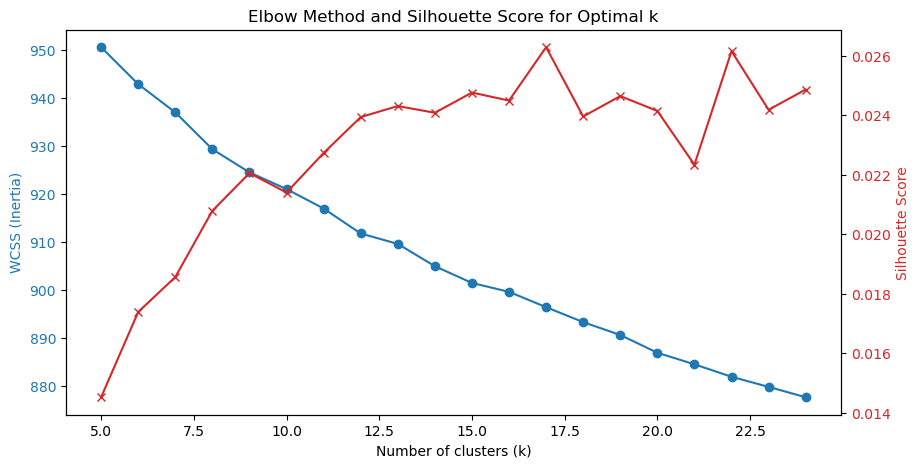

In [3]:
wcss = []
sil_scores = []
k_range = range(5, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(k_range, wcss, marker='o', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, sil_scores, marker='x', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method and Silhouette Score for Optimal k')
plt.show()

## 4. Final K-Means Execution

Analysis of the previous metrics suggests that $k=12$ provides a robust balance between model complexity and descriptive granularity. We now finalize our clustering model using this hyperparameter.

In [4]:
optimal_k = 12
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

## 5. Cluster Interpretation & Semantic Analysis

To understand the medical categories discovered by the model, we extract the top 8 features (words/bi-grams) for each cluster. These centroids represent the "typical" vocabulary for each symptomatic group.



In [5]:
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()

print("Top terms per cluster:")
for i in range(optimal_k):
    print(f"Cluster {i}: ", end='')
    for ind in order_centroids[i, :8]:
        print(f'{terms[ind]}, ', end='')
    print()

Top terms per cluster:
Cluster 0: pressure, chest, blood pressure, blood, tightness, pressure chest, feeling, feel, 
Cluster 1: hot, blister, touched, red, skin, small blister, small, swollen, 
Cluster 2: ear, pain, hear, left ear, pain ear, fever, right ear, cold, 
Cluster 3: makes, ache, shoulder, gives, feels, sore, outer, arm, 
Cluster 4: cough, chest, breathing, night, chest feels, tight, im, feels, 
Cluster 5: pain, head, starts, feel, throbbing pain, throbbing, vision, pain starts, 
Cluster 6: itchy, rash, new, raised, bumps, spots, hives, welts, 
Cluster 7: nose, throat, felt, mild, cold, cough, runny, day, 
Cluster 8: skin, feels, tight, sore, uncomfortable, lower, shoes, small, 
Cluster 9: doctor, ive, thirsty, weight, blood, losing, feel, im, 
Cluster 10: deep, breath, sharp, knee, deep breath, short, short breath, ache, 
Cluster 11: feel, pale, headaches, notice, skin, dizzy, looks, heart, 


## 6. High-Dimensional Visualization (t-SNE)

The TF-IDF matrix exists in a 1,000-dimensional space, making direct visualization impossible. We use **t-SNE (t-distributed Stochastic Neighbor Embedding)** to project these points into 2D.

**Why t-SNE?**
Unlike linear methods like PCA, t-SNE preserves the local neighborhood structure of the data, meaning documents that are semantically similar in high-dimensional space will stay close together in the plot. This allows us to visually confirm that our clusters are distinct and cohesive.



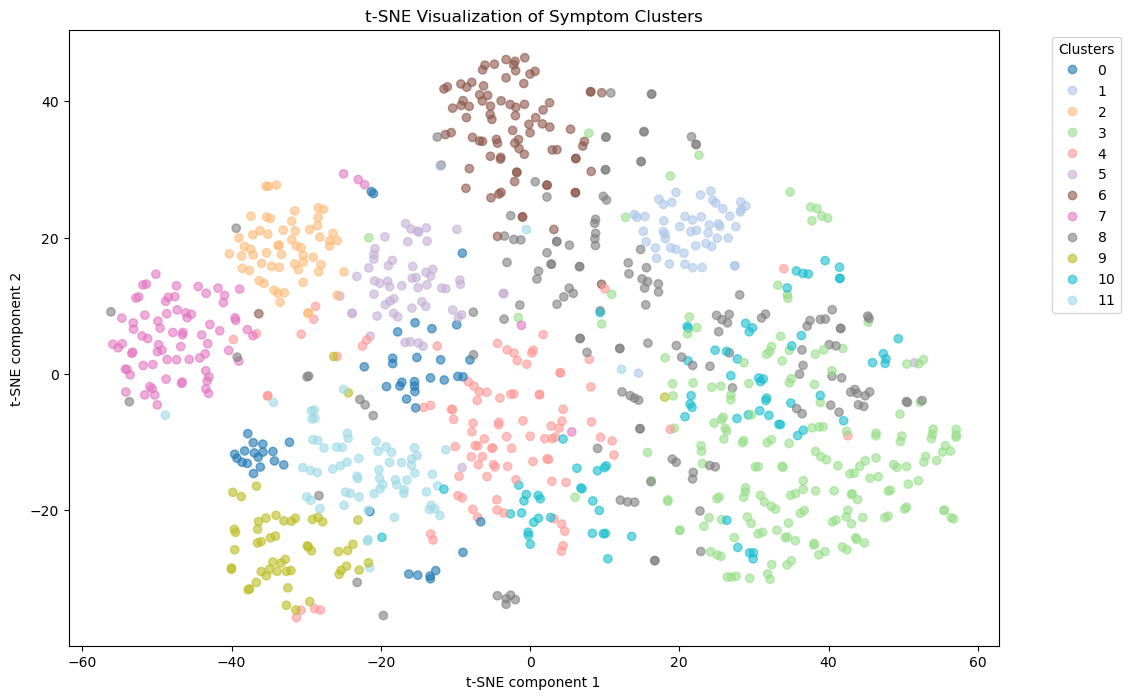

In [6]:
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X.toarray())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=df['cluster'], cmap='tab20', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE Visualization of Symptom Clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()


## 7. Conclusions & Strategic Insights

The unsupervised learning model has successfully stratified the patient testimonials into coherent medical domains. By analyzing the top terms, we can map the clusters to clinical categories:

| Cluster | Descriptive Keywords | Likely Clinical Category |
| :--- | :--- | :--- |
| **Cluster 1** | pressure, blood pressure, chest | Cardiovascular / Hypertensive |
| **Cluster 2** | cough, breath, breathing, chest | Respiratory |
| **Cluster 3** | hot, red, blister, burn | Thermal Injury (Burns) |
| **Cluster 5** | itchy, rash, hives, bumps | Dermatological / Allergic |
| **Cluster 7** | knee, leg, thigh, ache | Orthopedic (Lower Limb) |
| **Cluster 10** | thirsty, blood, weight, losing | Metabolic (Potential Diabetes) |
| **Cluster 11** | ear, fever, hear, left/right ear | Otolaryngology (Ear Infection) |

### Final Verdict
The model demonstrates high sensitivity to symptom-specific vocabulary. This unsupervised approach can serve as a powerful **automated triage tool**, allowing healthcare providers to prioritize patients based on the detected symptom group even before a formal diagnosis is rendered.